<a href="https://colab.research.google.com/github/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/blob/main/Praktikum6/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


## 2. Load Dataset

In [ ]:
data = load_breast_cancer()

# bagi fitur(X) dan target(y)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# bagi data latih 80% dan test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## A. Model Tanpa Batas Depth
1. Decision Tree Default

In [ ]:
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)

y_train_pred = tree_default.predict(X_train)
y_test_pred = tree_default.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))


Train Accuracy: 1.0
Test Accuracy : 0.9473684210526315


Analisis :
1. Apakah train accuracy mendekati 1.0?
Jawab : Ya, model Decision Tree berhasil menghapal seluruh data training dengan sempurna. Ini disebabkan karena tidak ada pembatasan kedalaman (no max_depth), sehingga Tree akan terus membelah sampai semua data terpisah sempurna.
2. Apakah test accuracy jauh lebih rendah?
Jawab : Ya, dibandingkan dengan hasil akurasi data training, karena data testing merupakan data baru, sedangakn model terlalu menghapal data training dan kurangnya generalisasi, yang merupakan tanda model overfitting.

## B. Tree Depth Tuning
1. Uji Berbagai Nilai max_depth

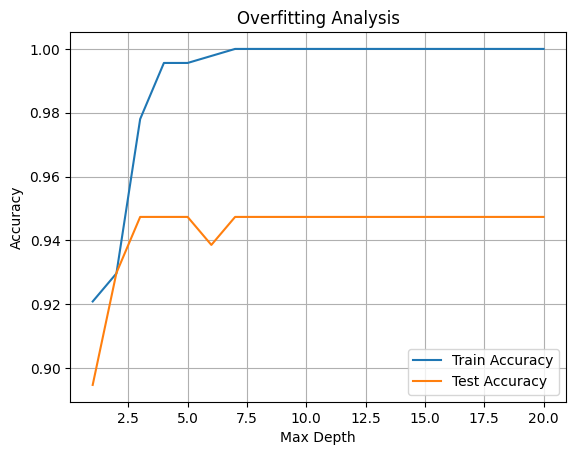

Train Accuracy: 1.0
Test Accuracy : 0.9473684210526315


In [ ]:
depths = range(1, 21)

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting Analysis")
plt.grid()
plt.show()


print("Train Accuracy:", max(train_acc))
print("Test Accuracy :", max(test_acc))

Analisis Grafik
1. Pada depth berapa train accuracy mulai 1.0?
Jawab : Nilai depth = 7, menunjukan model sudah menghafal data training secara sempurna.
2.	Pada depth berapa test accuracy paling tinggi?
Jawab : Nilai depth = 3 hingga 5, dilanjut 7 hingga 21 (Adanya penurunan akurasi pada rentang 5 hingga 7).
3.	Kapan model mulai overfit?
Jawab : mulai depth > 5, ketika akurasi train = 1 dan nilai akurasi test tidak meningkat/ stagnan.
4. Apa arti gap besar antara train dan test?
Jawab : Menunjukan model mengalami overfitting, yaitu nilai akurasi training sangat tinggi sedangkan nilai testing lebih rendah.

In [ ]:
# Tabel perbandingakn akurasi berbagai nilai max_depth
import pandas as pd

df = pd.DataFrame({
    "Depth": list(depths),
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc
})

print(df)

best_depth = test_acc.index(max(test_acc))
print("\nBest Depth:", depths[best_depth])
print("Best Test Accuracy:", test_acc[best_depth])

    Depth  Train Accuracy  Test Accuracy
0       1        0.920879       0.894737
1       2        0.929670       0.929825
2       3        0.978022       0.947368
3       4        0.995604       0.947368
4       5        0.995604       0.947368
5       6        0.997802       0.938596
6       7        1.000000       0.947368
7       8        1.000000       0.947368
8       9        1.000000       0.947368
9      10        1.000000       0.947368
10     11        1.000000       0.947368
11     12        1.000000       0.947368
12     13        1.000000       0.947368
13     14        1.000000       0.947368
14     15        1.000000       0.947368
15     16        1.000000       0.947368
16     17        1.000000       0.947368
17     18        1.000000       0.947368
18     19        1.000000       0.947368
19     20        1.000000       0.947368

Best Depth: 3
Best Test Accuracy: 0.9473684210526315


## C. Gini vs Entropy
1. Bandingkan Kriteria

In [ ]:
tree_gini = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
tree_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)

tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)

acc_gini = accuracy_score(y_test, tree_gini.predict(X_test))
acc_entropy = accuracy_score(y_test, tree_entropy.predict(X_test))

print("Accuracy (Gini):", acc_gini)
print("Accuracy (Entropy):", acc_entropy)


Accuracy (Gini): 0.9473684210526315
Accuracy (Entropy): 0.9473684210526315


Analisis :  
Apakah perbedaannya signifikan?
Jawab : Hasilnya sama, menunjukan bahwa kedua metode memiliki kemampuan yang setara dalam memisahkan data pada dataset yang digunakan.

## D. Visualisasi Tree
1. Plot Tree

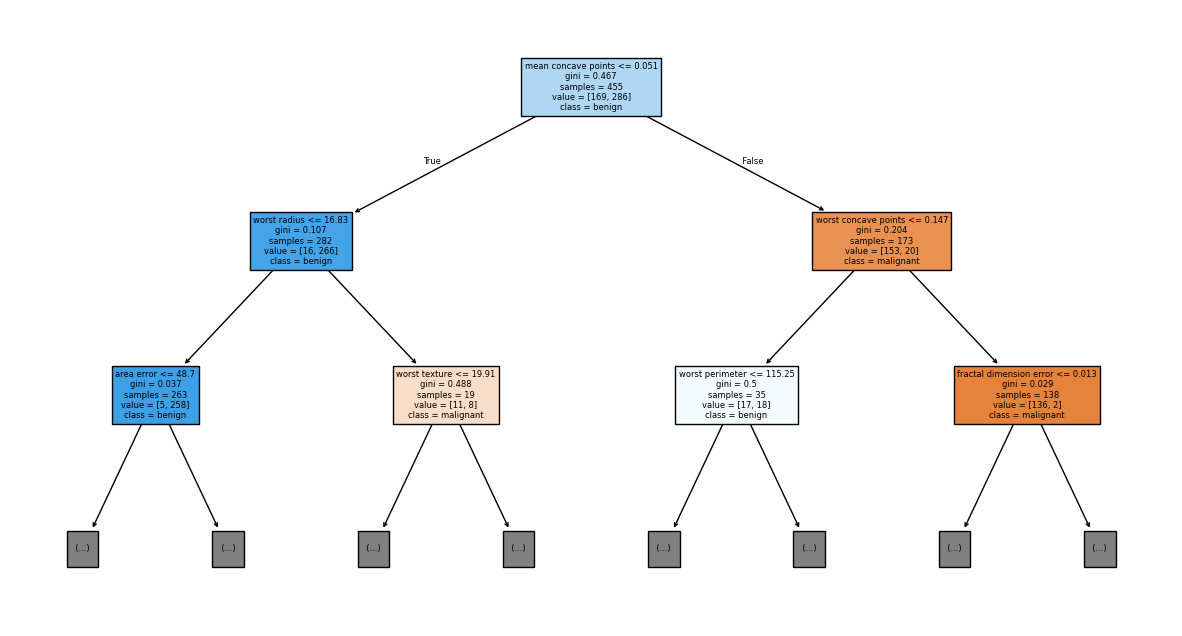

In [ ]:
plt.figure(figsize=(15,8))
plot_tree(
    tree_gini,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=2
)
plt.show()


## Tugas
1. Uji max_depth hingga 30
2. Tambahkan parameter : min_samples_split &	min_samples_leaf
3. Bandingkan dengan Logistic Regression
4. Lakukan 5-Fold Cross Validation.

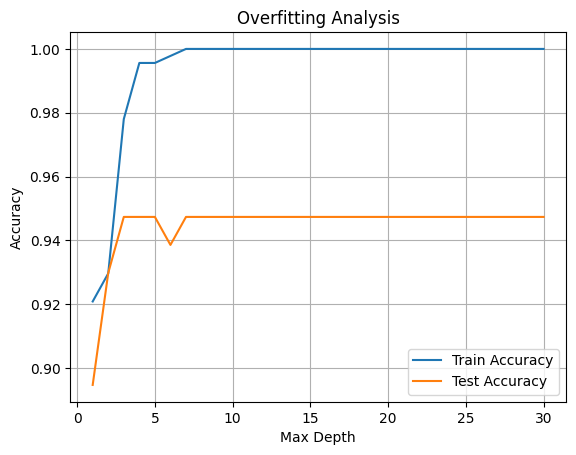

Train Accuracy: 1.0
Test Accuracy : 0.9473684210526315
Train acc = 1.0 pertama kali pada  : depth 7
Test  acc tertinggi (0.9474) pada : depth 3

Analisis:
  • Depth 1–3  : Underfitting → model terlalu sederhana
  • Depth 3       : Optimal      → bias-variance terbaik
  • Depth 7+      : Overfit      → train=1.0 tapi test stagnan


In [ ]:
# Uji max_depth hingga 30
depths = range(1, 31)

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting Analysis")
plt.grid()
plt.show()

print("Train Accuracy:", max(train_acc))
print("Test Accuracy :", max(test_acc))

first_overfit = next(d for d, a in zip(depths, train_acc) if a >= 1.0)
best_depth    = list(depths)[test_acc.index(max(test_acc))]
print(f"Train acc = 1.0 pertama kali pada  : depth {first_overfit}")
print(f"Test  acc tertinggi ({max(test_acc):.4f}) pada : depth {best_depth}")

print("\nAnalisis:")
print(f"  • Depth 1–{best_depth}  : Underfitting → model terlalu sederhana")
print(f"  • Depth {best_depth}       : Optimal      → bias-variance terbaik")
print(f"  • Depth {first_overfit}+      : Overfit      → train=1.0 tapi test stagnan")

In [ ]:
# Tambahkan parameter : min_samples_split & min_samples_leaf
tree_custom = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree_custom.fit(X_train, y_train)

y_train_pred = tree_custom.predict(X_train)
y_test_pred = tree_custom.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.978021978021978
Test Accuracy : 0.956140350877193


In [ ]:
# Bandingkan dengan Logistic Regression
# Decision Tree terbaik
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
dt_train = accuracy_score(y_train, dt_model.predict(X_train))
dt_test  = accuracy_score(y_test,  dt_model.predict(X_test))

# Logistic Regression (StandardScaler)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=10000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
lr_train = accuracy_score(y_train, lr_pipeline.predict(X_train))
lr_test  = accuracy_score(y_test,  lr_pipeline.predict(X_test))

print(f"{'Model':<30} {'Train Acc':>10} {'Test Acc':>10}")
print("=" * 55)
print(f"{'Decision Tree (max_depth='+str(best_depth)+')':<30} {dt_train:>10.4f} {dt_test:>10.4f}")
print(f"{'Logistic Regression':<30} {lr_train:>10.4f} {lr_test:>10.4f}")

Model                           Train Acc   Test Acc
Decision Tree (max_depth=3)        0.9780     0.9474
Logistic Regression                0.9868     0.9737


In [ ]:
# 5-Fold Cross Validation
from sklearn.model_selection import cross_val_score

model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Fold Cross Validation")
print("Accuracy tiap fold:\n", cv_scores)
print("Rata-rata Accuracy:", np.mean(cv_scores))

Fold Cross Validation
Accuracy tiap fold:
 [0.9122807  0.89473684 0.93859649 0.95614035 0.89380531]
Rata-rata Accuracy: 0.9191119391398852
